<a href="https://colab.research.google.com/github/thaninasm/ML-linear-regression-finance/blob/main/handwritten_digits_sklearn_fr.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Intro pratique au Deep learning avec Python

* comment accéder à vos données d'entraînement et les valider,
* comment créer et entraîner votre premier réseau de neurones sur ces données,
* comment utiliser le réseau entraîné et tester ses performances.


## Deep learning pour la classification



![Supervised learning](https://github.com/cbernet/maldives/raw/master/handwritten_digits_sklearn/supervised_learning.png)

On donne au réseau une succession d'exemples d'entraînement (INPUT). Chaque exemple comprend:

* l'image d'un chiffre
* une étiquette, qui nous dit quel est le chiffre réellement représenté par l'image (OUTPUT). L'étiquette pourrait avoir été renseignée par la personne qui a écrit ce chiffre.

Dans le schéma ci-dessus, la première image est traitée par le réseau de neurone, qui nous dit que l'image est un 9.

Au début du processus d'apprentissage, les connexions entre les neurones dans le réseau sont aléatoires, et le réseau n'est pas encore capable de se rendre utile en quoi que ce soit; il se contente de nous donner une réponse aléatoire.

La réponse est comparée à l'étiquette. Dans ce cas, la réponse (9) est différente de l'étiquette (en fait, ce chiffre est un 3), et un retour est donné au réseau de neurones pour qu'il puisse s'améliorer. Les connexions entre les neurones sont modifiées, en favorisant celles qui tendent à donner une réponse correcte.

Après la modification,  le réseau traite l'exemple suivant, etc. Il apprend selon un processus itératif.

Le nombre d'exemples nécessaires pour entraîner le réseau correctement peut être de l'ordre de quelques centaines pour des réseaux avec une architecture simple, ou de millions pour les réseaux complexes.


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

## L'échantillon de chiffres

scikit-learn fournit plusieurs échantillons test. Chargeons l'échantillon de chiffres manuscrits:

In [ ]:
from sklearn import datasets
digits = datasets.load_digits()

Voir ce que contient notre échantillon `digits`:

In [ ]:
dir(digits)

['DESCR', 'data', 'feature_names', 'frame', 'images', 'target', 'target_names']

Voyons quel est le type des objets `digits.images` et `digits.target` :

In [ ]:
print (type(digits.images))
print (type(digits.target))

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


`images` et `target` sont tous deux des `ndarrays` (tableaux à N dimensions). Voyons leur taille:  

In [ ]:
digits.images.shape

(1797, 8, 8)

`digits.image` est un tableau à 3 dimensions. La première indexe les images, et il y en a 1797. Les deux dimensions suivantes correspondent aux coordonnées x et y des pixels de chaque image. Chaque image a donc 8x8 = 64 pixels. On peut visualiser `digits.images` en 3D comme une pile d'images de 8x8 pixels chacune.

Imprimons les données de la première image 8x8. Chaque case dans le tableau correspond à un pixel, et la valeur dans cette case est la quantité de noir dans le pixel.

In [ ]:
print (digits.images[0])

[[ 0.  0.  5. 13.  9.  1.  0.  0.]
 [ 0.  0. 13. 15. 10. 15.  5.  0.]
 [ 0.  3. 15.  2.  0. 11.  8.  0.]
 [ 0.  4. 12.  0.  0.  8.  8.  0.]
 [ 0.  5.  8.  0.  0.  9.  8.  0.]
 [ 0.  4. 11.  0.  1. 12.  7.  0.]
 [ 0.  2. 14.  5. 10. 12.  0.  0.]
 [ 0.  0.  6. 13. 10.  0.  0.  0.]]


Affichons l'image graphiquement (parfois, l'image n'apparaît pas. Si c'est le cas, il suffit de ré-exécuter la cellule ci-dessous avec MAJ+entrée):

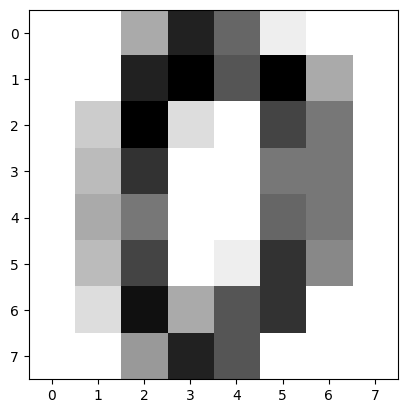

In [ ]:
import matplotlib.pyplot as plt
plt.imshow(digits.images[0],cmap='binary')

La résolution de l'image est mauvaise (elle a été réduite pour créer les dataset test de scikit-learn pour être léger et permettre un apprentissage rapide de l'algo)

Maintenant, regardons l'attribut `digits.target` :

In [ ]:
print (digits.target.shape)
print (digits.target)

(1797,)
[0 1 2 ... 8 9 8]


C'est un tableau à une dimension, avec 1797 cases. Il contient les étiquettes, c'est à dire les chiffres auxquels correspondent chaque image. Par exemple, la première étiquette est 0, et correspond à l'image ci-dessus.

La fonction suivante permet d'afficher plusieurs images d'un coup, ainsi que les étiquettes correspondantes:

In [ ]:
def plot_multi(i):
    '''Plots 16 digits, starting with digit i'''
    nplots = 16
    fig = plt.figure(figsize=(15,15))
    for j in range(nplots):
        plt.subplot(4,4,j+1)
        plt.imshow(digits.images[i+j], cmap='binary')
        plt.title(digits.target[i+j])
        plt.axis('off')
    plt.show()

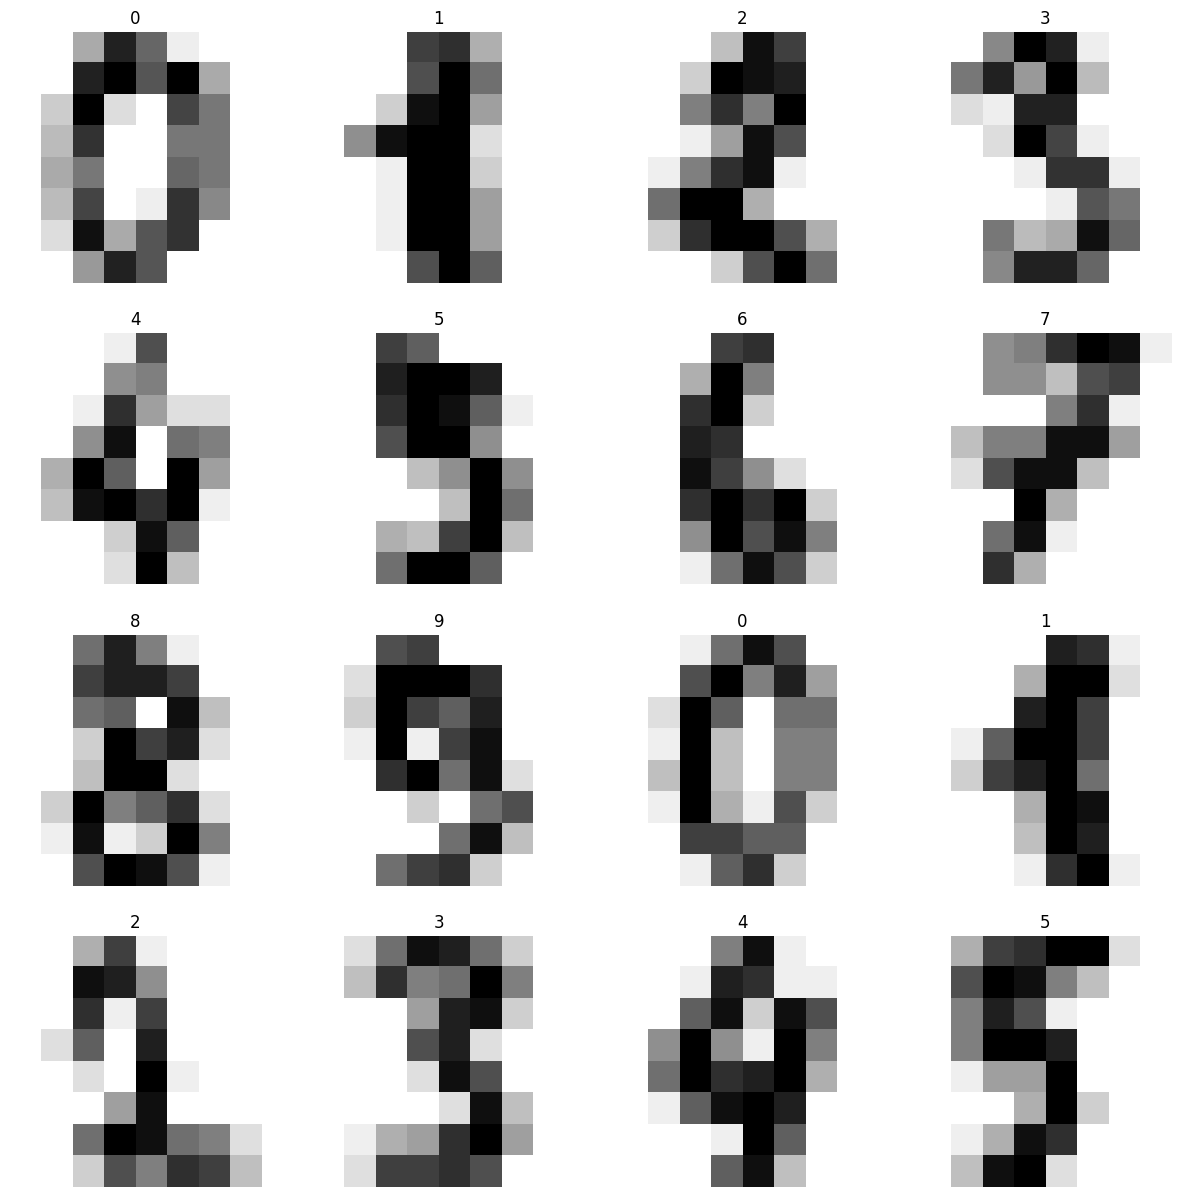

In [ ]:
plot_multi(0)

Vous pouvez afficher les images suivantes en appelant `plot_multi(16)`, `plot_multi(32)`, etc.

Vous verrez probablement qu'avec une si mauvaise résolution, ce n'est pas si facile de reconnaître certains de ces chiffres, même pour notre cerveau humain hautement performant. Dans ces conditions, le réseau de neurones sera lui aussi limité par la faible qualité des images. Pouvons-nous créer un réseau de neurones au moins aussi performant qu'un humain? Ce serait déjà bien!


## Création du réseau de neurones et préparation de l'échantillon d'entraînement

[scikit-learn](https://scikit-learn.org) permet de créer, d'entraîner, et d'évaluer un réseau de neurones en quelques lignes de code.  

Nous allons créer un réseau extrêmement simple, avec seulement trois couches:

* une **couche d'entrée** (*input layer*), avec 64 neurones (1 par pixel de l'image). Chacun se contente de prendre la valeur en entrée et de la transmettre aux neurones de la couche suivante.
* une **couche cachée** (*hidden layer*) avec 15 neurones. Nous aurions pu choisir un autre nombre de neurones, et ajouter des couches avec différents nombres de neurones
* une **couche de sortie** (*output layer*) avec 10 neurones, correspondant à nos 10 classes de chiffres, de 0 à 9

On dit que ce type de réseau est *dense*, ce qui veut dire que dans chaque couche, chaque neurone est connecté avec tous les neurones des couches précédentes et suivantes.


![Simple dense network](https://github.com/cbernet/maldives/raw/master/handwritten_digits_sklearn/simple_dense.png)

La couche d'entrée demande que nos valeurs des pixel d'une image soient entrés à la queue leu leu, on va donc tranformer notre tableau 2D (8x8 pixes) en valeurs (64) écrites les unes à la suite des autres:

In [ ]:
y = digits.target
x = digits.images.reshape((len(digits.images), -1))
x.shape

(1797, 64)

Maintenant, nous avons 1797 images aplaties. Séparons maintenant notre échantillon en 2 parties, les données d'entrainement et les données de test.

In [ ]:
x_train = x[:1000]
y_train = y[:1000]
x_test = x[1000:]
y_test = y[1000:]

Les 1000 premières images seront utilisées pour l'entraînement. Le reste de l'échantillon sera utilisé ensuite pour évaluer les performances du réseau (données de test).

Nous pouvons maintenant créer le réseau de neurones. Voici le détail des autres paramètres utilisés par cette fonction:
* **hidden_layer_sizes=(15,)** : Définit l'architecture du réseau avec une seule couche cachée contenant 15 neurones. Le modèles comprendra automatiquement la taille des couches d'entrée et de sortie.
* **activation='logistic' **: Utilise la fonction d'activation sigmoïde (aussi appelée logistique), qui transforme les valeurs en sortie en probabilités dans l'intervalle [0,1].
* **alpha=1e-4 **: Paramètre de régularisation L2 (aussi appelé weight decay) qui aide à éviter le **surapprentissage** en pénalisant les grands poids.
* **solver='sgd'** : Utilise la descente de gradient stochastique comme algorithme d'optimisation pour ajuster les poids du réseau pendant l'apprentissage.
* **tol=1e-4**: Définit le seuil de tolérance pour l'arrêt de l'entraînement. L'algorithme s'arrête quand le gain entre chaque époque devient inférieur à cette valeur.
* **random_state=1**: Fixe la graine aléatoire pour assurer la reproductibilité des résultats à chaque exécution.
* **learning_rate_init=.1** : Définit le taux d'apprentissage initial à 0.1, qui détermine la taille des pas lors de l'optimisation des poids.
* **verbose=True** : Active l'affichage des messages de progression pendant l'entraînement du modèle.

In [ ]:
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(hidden_layer_sizes=(15,), activation='logistic', alpha=1e-4,
                    solver='sgd', tol=1e-4, random_state=1,
                    learning_rate_init=.1, verbose=True)


Enfin, entraînons le réseau NN. A chaque itération, le NN calcule son erreur de prédiction (loss). Plus la valeur est petite, moins il fait d'erreur. Au fil des itérations, on devrait voir l'erreur diminuer (il apprend et se trompe moins souvent).

In [ ]:
mlp.fit(x_train,y_train)

Iteration 1, loss = 2.22958289
Iteration 2, loss = 1.91207743
Iteration 3, loss = 1.62507727
Iteration 4, loss = 1.32649842
Iteration 5, loss = 1.06100535
Iteration 6, loss = 0.83995513
Iteration 7, loss = 0.67806075
Iteration 8, loss = 0.55175832
Iteration 9, loss = 0.45840445
Iteration 10, loss = 0.39149735
Iteration 11, loss = 0.33676351
Iteration 12, loss = 0.29059880
Iteration 13, loss = 0.25437208
Iteration 14, loss = 0.22838372
Iteration 15, loss = 0.20200554
Iteration 16, loss = 0.18186565
Iteration 17, loss = 0.16461183
Iteration 18, loss = 0.14990228
Iteration 19, loss = 0.13892154
Iteration 20, loss = 0.12833784
Iteration 21, loss = 0.12138920
Iteration 22, loss = 0.11407971
Iteration 23, loss = 0.10677664
Iteration 24, loss = 0.10037149
Iteration 25, loss = 0.09593187
Iteration 26, loss = 0.09250135
Iteration 27, loss = 0.08676698
Iteration 28, loss = 0.08356043
Iteration 29, loss = 0.08209789
Iteration 30, loss = 0.07649168
Iteration 31, loss = 0.07410898
Iteration 32, los

MLPClassifier(activation='logistic', hidden_layer_sizes=(15,),
              learning_rate_init=0.1, random_state=1, solver='sgd',
              verbose=True)

L'entraînement était très rapide car le réseau de neurones est simple et car l'échantillon d'entraînement est petit. Maintenant que le réseau de neurones est prêt, voyons ce qu'il prédit pour les images de nos données de test (images qu'il n'a encore jamais vues)

In [ ]:
predictions = mlp.predict(x_test)
predictions[:50]
# on regarde juste la prédiction pour
# les 50 premières images dans l'échantillon de test

array([1, 4, 0, 5, 3, 6, 9, 6, 1, 7, 5, 4, 4, 7, 2, 8, 2, 2, 5, 7, 9, 5,
       4, 4, 9, 0, 8, 9, 8, 0, 1, 2, 3, 4, 5, 6, 7, 8, 3, 0, 1, 2, 3, 4,
       5, 6, 7, 8, 5, 0])

Ces prédictions devraient être assez proches des étiquettes de l'échantillon de test, vérifions cela ( comparez les valeurs de ces deux tableaux)

In [ ]:
y_test[:50]
# étiquettes pour les 50 premiers exemples de l'échantillon de test

array([1, 4, 0, 5, 3, 6, 9, 6, 1, 7, 5, 4, 4, 7, 2, 8, 2, 2, 5, 7, 9, 5,
       4, 4, 9, 0, 8, 9, 8, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 0, 1, 2, 3, 4,
       5, 6, 7, 8, 9, 0])

Pas mal! On voit que la totalité ou presque des prédictions correspondent à la vérité.

Pour valider ce qu'on voit à l'oeil nu, nous pouvons calculer la *performance (accuracy)* du classement, qui est la probabilité de classer un chiffre dans la bonne catégorie. Là encore, scikit-learn nous fournit un outil tout prêt pour cela:

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, predictions)

0.9146800501882058

Cette valeur est la probabilité que les chiffres de l'échantillon de test soient classés dans la bonne catégorie.
Ainsi, dans 91.6% des cas, le classement est correct.

**Nous avons donc obtenu une précision de 91.6% avec ce réseau de neurones très simple. Pas mal!**

On pourrait sans doute améliorer la performance en cherchant à optimiser les paramètres (par exemple le learning rate) ou en testant d'autres architectures (ajouter des couches au réseau NN par exemple)